In [5]:
import pandas as pd
import sqlite3
conn = sqlite3.connect('student_performance.db')
cursor = conn.cursor()
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

SQL query to find the average programming score for female students only

In [6]:
query1 = """SELECT AVG(programming_score) 
            AS avg_programming_score
            FROM students 
            WHERE gender = 'Female';"""
result1 = run_query(query1,"Average programming score for female students")


Average programming score for female students
 avg_programming_score
                  70.2


Difference between WHERE and HAVING

| Clause / Operator | What It Filters | When It Runs | Can It Use Aggregates? (SUM, AVG, etc.) |
| :--- | :--- | :--- | :--- |
| **WHERE** | Individual rows | Before data is grouped | No |
| **LIKE** | Text patterns inside rows | During the WHERE step | No |
| **HAVING** | Grouped summary data | After data is grouped |  Yes |

In [7]:
#eg for where clause
query2 = """SELECT name FROM students WHERE math_score>90"""
result2 = run_query(query2,description="Where clause example")
#eg for Having clause
query3 = """SELECT department,ROUND(AVG(math_score),2) as math_score FROM students GROUP BY department HAVING AVG(math_score)>60"""
result3 = run_query(query3,description="Having clause example")


Where clause example
          name
    Arjun Nair
    Ananya Das
   Tanvi Mehta
Akanksha Yadav

Having clause example
      department  math_score
           Civil       63.40
Computer Science       85.62
     Electronics       71.00
      Mechanical       71.00


SQL query to find all departments where the average attendance is above 85%

In [8]:
query4 = """SELECT department 
            FROM students 
            GROUP BY department
            HAVING  AVG(attendance_percentage) > 85;"""
result4 = run_query(query4,description="Departments with avg attendance > 85%")


Departments with avg attendance > 85%
      department
Computer Science


 What does pd.read_sql_query() return? What two arguments does it require?

`pd.read_sql_query()` return the output of the SELECT query in sqlite3
The required two arguments are
- SQL query
- conn (The connection to the database)   


Average programming score by dept
      department  avg_prog
           Civil 40.600000
Computer Science 89.230769
     Electronics 61.500000
      Mechanical 49.333333


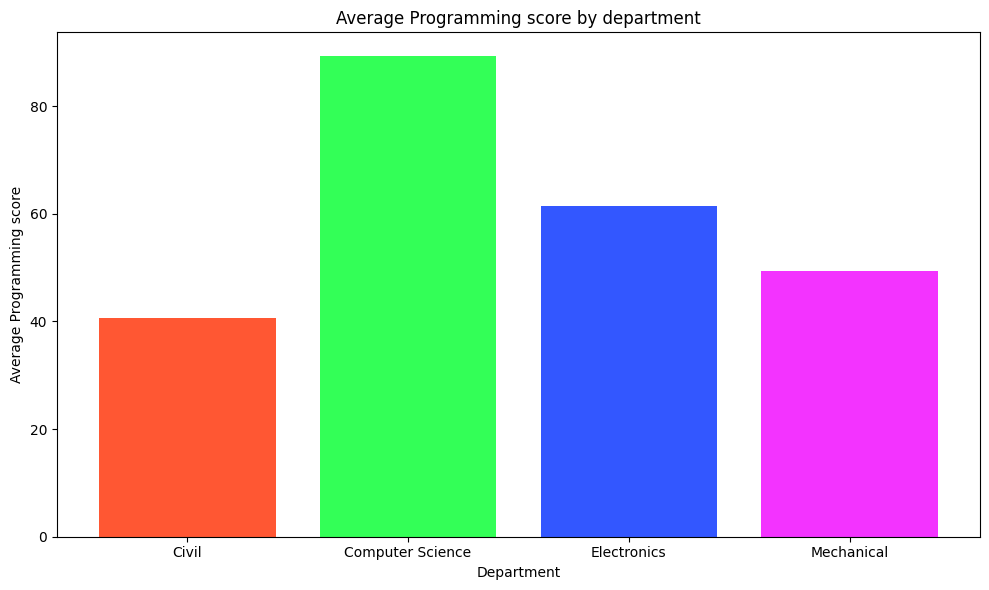

In [9]:
import matplotlib.pyplot as plt
query5 = """SELECT Department,AVG(programming_score) 
            AS avg_prog FROM 
            students GROUP BY 
            department;"""
result5 = run_query(query5,"Average programming score by dept")

colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#33FFF5']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.bar(result5['department'],result5['avg_prog'],color=colors)
ax.set_xlabel('Department')
ax.set_ylabel('Average Programming score')
ax.set_title('Average Programming score by department')
plt.tight_layout()
plt.show()

#### Extra questions

In [10]:
import sqlite3
import pandas as pd

try:
    conn.close()
except:
    pass

conn = sqlite3.connect('student_performance.db', timeout=30)

dept_data = {
    'dept_code': ['CS', 'EC', 'ME', 'CE'],
    'dept_name': ['Computer Science', 'Electronics', 'Mechanical', 'Civil'],
    'hod_name': ['Dr.Sharma', 'Dr.Reddy', 'Dr.Patel', 'Dr.Kumar'],
    'established': [1985, 1988, 1972, 1965],
    'intake': [60, 60, 60, 60]
}
dept_df = pd.DataFrame(dept_data)
dept_df.to_sql('departments', conn, if_exists='replace', index=False)

print("--- Departments Table Created ---")
print(dept_df.to_string(index=False), "\n")

student_data = {
    'student_id': [101, 102, 103, 104],
    'name': ['Ananya Das', 'Tanvi Mehta', 'Arjun Nair', 'Amit Bose'],
    'department': ['Computer Science', 'Electronics', 'Mechanical', 'Civil'],
    'programming_score': [88, 72, 95, 64]
}
df = pd.DataFrame(student_data)

dept_map = {
    'Computer Science': 'CS',
    'Electronics': 'EC',
    'Mechanical': 'ME',
    'Civil': 'CE'
}
df['dept_code'] = df['department'].map(dept_map)

df.to_sql('students', conn, if_exists='replace', index=False)
print("--- Students Table Created & Synced ---")
print(df.to_string(index=False), "\n")


OperationalError: database is locked